# Notebook 02 - Estimation Analyst

## Research Questions

RQ1:
Berapa estimasi probabilitas sebuah issue bug (is_bug = 1) dapat diselesaikan dalam waktu <= 7 hari, dan seberapa tinggi tingkat ketidakpastian estimasi tersebut?

RQ2:
Berapa rata-rata jumlah issue bug yang diselesaikan setiap minggu pada repositori Pandas, dan apakah rata-rata tersebut berbeda secara signifikan dari nilai yang diasumsikan?


|Nama|Role|
|---|---|
|Elpa Padila| Estimation Analyst|

## Penggunaan AI

**Anggota:** [Elpa Padila] — [Estimation Analyst] | 
**Tools used:** [Gemini]

| Task | Tool | Prompt summary | Output modified? |
| ----------------------------- | ------ | ------------------------------------------------- | ----------------------- |
| format penulisan simbol matematika ($\alpha, \beta, \theta$) di Markdown | Gemini | "bagaimana membuat simbol alpha, beta, theta, dll di markdown cell?" | Ya - disesuaikan dengan kebutuhan |
| pembuatan template alur analisis data (Pipeline) di Notebook 02 | Gemini | "buatkan template kode Python untuk analisis statistik deskriptif dan estimasi parameter. Saya ingin kodenya dibagi menjadi beberapa langkah..." | Ya - Kerangka urutan kerja (step-by-step) dari AI diambil sebagai acuan, namun rumus matematika internal di dalam fungsi Notebook dihapus dan digantikan dengan pemanggilan modul fungsi eksternal dari src.estimator sesuai aturan tugas |

**Ditulis tanpa AI:** Sel Interpretasi, Kesimpulan notebook yang akan diteruskan ke anggota selanjutnya.

## Inisialisasi dan pemanggilan function dari src/estimator.py


In [14]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from src.estimator import (
    mle_bernoulli, 
    mle_poisson, 
    beta_posterior, 
    log_likelihood_bernoulli, 
    log_likelihood_poisson
)

Di bagian ini dilakukan import library dan memanggil fungsi yang ada di modul src.estimator 

## RQ1: Menghitung estimasi probabilitas sebuah issue bug (is_bug = 1) dapat diselesaikan dalam waktu <= 7 hari

### 1. Persiapan Data

In [13]:
# 1. MUAT DATA BERSIH 
dataset_path = os.path.join(BASE_DIR, 'data', 'clean', 'dataset_final.csv')
df_final = pd.read_csv(dataset_path)

# 2. Saring data untuk kebutuhan analisis RQ 
df_bugs = df_final[df_final['is_bug'] == 1].copy()
df_bugs['closed_at'] = pd.to_datetime(df_bugs['closed_at'])
df_bugs['created_at'] = pd.to_datetime(df_bugs['created_at'])

print(f"Total sampel issue bug yang siap dianalisis: {len(df_bugs)} baris")
df_bugs[['number', 'type', 'is_bug', 'duration_days']].head()

Total sampel issue bug yang siap dianalisis: 778 baris


,number,type,is_bug,duration_days
0,65685,ISSUE,1,2.04
3,65550,ISSUE,1,6.53
4,65518,ISSUE,1,0.26
10,65369,ISSUE,1,9.92
12,65357,ISSUE,1,9.21


Dilakukan pemuatan data untuk mengambil dataset_final.csv (hasil cleaning Data Engineer). Setelahnya, data tersebut disaring dengan cara mengambil issue yang berstatus bug saja (is bug == 1) lalu disimpan ke variabel df_bugs untuk keperluan menjawab RQ1 dan RQ2. Kolom tanggal dibuat menjadi format waktu (pd.to_datetime) agar nanti bisa dihitung durasinya dan dikelompokkan perminggu.
Setelah itu, dilakukan pengecekan untuk menghitung berapa banyak baris data bugs yang siap dianalisis (len(df_bugs)) dan menampilkan 5 sampel baris teratas dari kolom-kolom pilihan.

### 2. Membuat Variabel Bernoulli

In [7]:
array_biner_rq1 = (df_bugs['duration_days'] <= 7).astype(int).values
k_sukses = int(np.sum(array_biner_rq1))
n_total = int(len(array_biner_rq1))
m_gagal = int(n_total - k_sukses)

print(f"Jumlah bug selesai cepat (<= 7 hari) [k] : {k_sukses} kasus")
print(f"Jumlah bug selesai lama (> 7 hari)  [m] : {m_gagal} kasus")
print(f"Total sampel Bernoulli               [n] : {n_total} issue")

Jumlah bug selesai cepat (<= 7 hari) [k] : 415 kasus
Jumlah bug selesai lama (> 7 hari)  [m] : 363 kasus
Total sampel Bernoulli               [n] : 778 issue


Pembuatan variabel bernoulli dilakukan dengan cara pengecekan jika duration_days <= 7 maka akan menghasilkan true dan jika lebih dari 7 maka akan menghasilkan false. Jawaban tersebut dikonversi ke integer astype(int), true = 1 dan false = 0 lalu disimpan dalam bentuk array. Maka diperoleh data berikut:
- jumlah bug selesai cepat atau kejadian sukses (k) sebanyak 415 kasus
- jumlah bug selesai lama atau kejadian gagal (m) sebanyak 363 kasus
- total keseluruhan sampel data (n) adalah 778 issues.
Angka ini menunjukan bahwa mayoritas bug (53.34%) berhasil dituntaskan dalam waktu cepat.

### 3. MLE Bernoulli & Estimasi Bayesian

In [8]:
theta_hat = mle_bernoulli(array_biner_rq1)
parameter_bayesian = beta_posterior(k_sukses, m_gagal)

print(f"Nilai Estimasi Titik (MLE \u03b8^): {theta_hat:.4f}")
print(f"Parameter Posterior Beta     : Alpha (\u03b1) = {parameter_bayesian['alpha']}, Beta (\u03b2) = {parameter_bayesian['beta']}")

Nilai Estimasi Titik (MLE θ^): 0.5334
Parameter Posterior Beta     : Alpha (α) = 416, Beta (β) = 364


Dari hasil perhitungan di atas, diperoleh dua kesimpulan untuk menjawab RQ1:
Nilai MLE ($\hat{\theta}$ = 0.5334): artinya, peluang sebuah issue bug di repositori Pandas selesai dalam waktu cepat (<= 7 hari) adalah sebesar 53.34%
Parameter Bayesian ($\alpha$ = 416, $\beta$ = 364): pasangan angka yang besar ini membuktikan bahwa tingkat ketidakpastian estimasi kami sangat rendah (sangat akurat) karena didukung oleh jumlah sampel data yang banyak (n = 778).

### 4. Log Likelihood Bernoulli

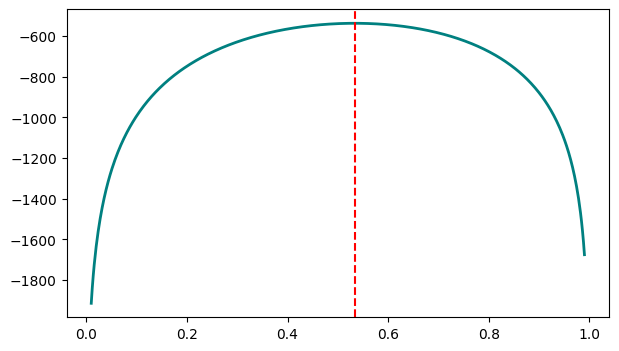

In [9]:
kandidat_theta = np.linspace(0.01, 0.99, 500)
nilai_ll_bernoulli = [log_likelihood_bernoulli(t, k_sukses, n_total) for t in kandidat_theta]

plt.figure(figsize=(7, 4))
plt.plot(kandidat_theta, nilai_ll_bernoulli, color='teal', lw=2)
plt.axvline(x=theta_hat, color='red', linestyle='--')
plt.show()

Grafik di atas memperlihatkan kurva fungsi Log-Likelihood berbentuk cembung ke atas. Garis putus-putus merah merepresentasikan nilai estimasi  $\hat{\theta} = 0.5334$ yang didapatkan melalui metode MLE.
Secara visual, tampak jelas bahwa garis merah tersebut memotong tepat di puncak tertinggi kurva. Ini membukatikan bahwa nilai probabilitas 53.34% merupakan titik parameter yang paling optimal dan paling didukung data historis 778 issue bug kelompok kami

### 5. Kesimpulan untuk RQ1

Dari 778 sampel bug repositori Pandas, diperoleh mayoritas sebanyak 415 kasus (53.34%)  selesai cepat (<= 7 hari). Melalui metode klasik MLE Bernoulli, dapat disimpulkan probabilitas sebuah bug baru selesai cepat adalah 53.34% ($\hat{\theta} = 0,5334$)
Pendekatan Bayesian menghasilkan parameter Posterior Beta yang besar ($\alpha = 416, \beta = 364$), membuktikan bahwa tingkat ketidakpastian estimasi ini sangat rendah (sangat akurat) berkat volume data yang kuat. Hal ini terverifikasi secara visual lewat kurva log-likelihood yang memuncut di titik $\hat{\theta}$. Angka ini siap diteruskan ke Notebook 3

## RQ2: Estimasi Laju Penyelesaian Bug Mingguan

### 1. Penghitungan bug perminggu

In [10]:
bug_per_minggu = df_bugs.set_index('closed_at').resample('W').size().values
print(f"Total minggu pengamatan: {len(bug_per_minggu)} minggu")
print("Sampel frekuensi penyelesaian bug per minggu:", bug_per_minggu[:5])

Total minggu pengamatan: 104 minggu
Sampel frekuensi penyelesaian bug per minggu: [ 1 11  8 11  5]


Kode ini merangkap data harian menjadi jumlah bug selesai per minggu selama total 104 minggu. Hasil rekap frekuensi ini (misal minggu awal berkisar 1–11 kasus) menjadi modal utama kelompok kami untuk menghitung parameter MLE Poisson di sel selanjutnya.

### 2. MLE Poisson

In [11]:
lambda_hat = mle_poisson(bug_per_minggu)
print(f"Estimasi Parameter Lambda (MLE \u03bb^): {lambda_hat:.4f} bug/minggu")

Estimasi Parameter Lambda (MLE λ^): 7.4808 bug/minggu


Melalui metode MLE Poisson berdasarkan 104 minggu pengamatan, diperoleh nilai estimasi laju $\hat{\lambda} = 7.4808$. Hal ini menyimpulkan bahwa secara rata-rata historis, tim pengembang repositori Pandas mampu menyelesaikan sekitar 7 hingga 8 issue bug setiap minggunya.

### 3. Log Likelihood Poisson

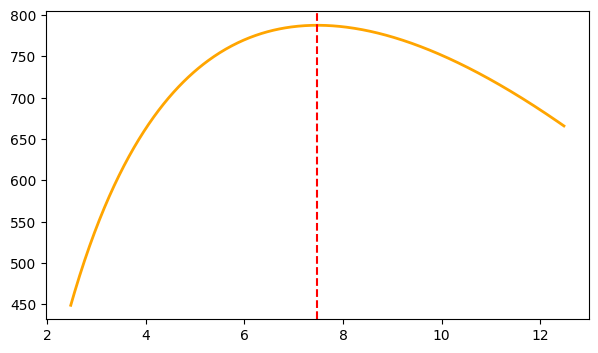

In [12]:
kandidat_lambda = np.linspace(max(0.1, lambda_hat - 5), lambda_hat + 5, 500)
nilai_ll_poisson = [log_likelihood_poisson(l, bug_per_minggu) for l in kandidat_lambda]

plt.figure(figsize=(7, 4))
plt.plot(kandidat_lambda, nilai_ll_poisson, color='orange', lw=2)
plt.axvline(x=lambda_hat, color='red', linestyle='--')
plt.show()

Grafik menunjukkan kurva fungsi Log-Likelihood Poisson berbentuk cembung. Garis putus-putus merah ($\hat{\lambda} = 7.4808$) memotong tepat di puncak tertinggi kurva. Hal ini membuktikan secara empiris bahwa nilai rata-rata tersebut adalah parameter paling optimal yang paling didukung oleh data 104 minggu pengamatan.

### 4. Kesimpulan untuk RQ2

Analisis terhadap 104 minggu data pengamatan repositori Pandas menggunakan metode MLE Poisson menghasilkan estimasi laju $\hat{\lambda} = 7.4808$. Artinya, tim pengembang secara konsisten menyelesaikan rata-rata 7.48 issue bug per minggu. Secara empiris, nilai parameter ini terbukti valid dan akurat karena berada tepat di titik stasioner (puncak maksimum) kurva fungsi Log-Likelihood Poisson. Parameter laju mingguan ini bersifat final dan siap digunakan sebagai landasan pengujian hipotesis.

## Ringkasan dan terusan data untuk member selanjutnya

Seluruh tahapan pemodelan parameter untuk menjawab RQ1 dan RQ2 telah selesai dieksekusi dengan hasil sebagai berikut:
1. **Output RQ1 (Bernoulli & Bayesian):** Nilai estimasi probabilitas sukses ($\hat{\theta}$) adalah **0.5334** dengan parameter posterior **Alpha ($\alpha$) = 416** dan **Beta ($\beta$) = 364**.
2. **Output RQ2 (Poisson):** Nilai estimasi laju penyelesaian mingguan ($\hat{\lambda}$) adalah **7.4808 bug/minggu** berdasarkan total basis data **104 minggu pengamatan**.

#### Data Terusan untuk Member Selanjutnya (Inference Layer)

Sesuai dengan pembagian alur kerja pada berkas README, variabel parameter yang telah dikunci (stored) dalam kondisi valid ini siap dioper ke notebook masing-masing:

1. Untuk Member C - Dilanjutkan ke Notebook `03_confidence_interval.ipynb`
Bisa langsung memanggil nilai variabel estimasi ini untuk melakukan pengujian proporsi, pembuatan *Confidence Interval* (CI) Bernoulli, serta analisis kredibilitas Bayesian untuk menjawab sisa pertanyaan pada RQ1:
- k_sukses = 415
- n_total = 778
- alpha_posterior = 416
- beta_posterior = 364

2. Untuk Member D - Dilanjutkan ke Notebook `04_hypothesis_testing.ipynb`
Bisa langsung memanggil nilai variabel estimasi ini untuk melakukan analisis Confidence Interval Poisson serta pengujian signifikansi statistik (Z-Test) terhadap nilai yang diasumsikan pada RQ2:
- lambda_hat = 7.4808
- n_weeks = 104

----------------------------------------------------
*Elpa Padila - Estimation Analyst*